## Project Name: Employee Attrition Analyzer   
#### Name: Syeda Taqiya Noman
#### Roll No: 24F-AI-026
#### Date: 8th October 2026

1. Employee Attrition Analyzer  
Analyze a dataset of employee records to predict whether an employee is likely to leave the company.  
Dataset: IBM HR Analytics Employee Attrition & Performance  
Integration:  
o Clean and preprocess categorical and numerical data.  
o Train and compare Logistic Regression, Decision Tree, and Random Forest
models.  
o Evaluate results using confusion matrix, F1 score, and feature importance
visualization.  

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, f1_score

In [81]:
# Load dataset
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(df.head())

X = df.drop("Attrition", axis=1)
y = df["Attrition"]

   Age Attrition  ... YearsSinceLastPromotion  YearsWithCurrManager
0   41       Yes  ...                       0                     5
1   49        No  ...                       1                     7
2   37       Yes  ...                       0                     0
3   33        No  ...                       3                     0
4   27        No  ...                       2                     2

[5 rows x 35 columns]


In [82]:
# Preprocessing

print("Missing Values:", df.isnull().sum().sum())
df = df.fillna(df.mean(numeric_only=True))

df = df.drop(columns=["EmployeeCount", "StandardHours", "Over18", "EmployeeNumber"])

df["Attrition"] = df["Attrition"].map({"Yes":1, "No":0})
df = pd.get_dummies(df, drop_first=True, dtype=int)

X = df.drop(columns="Attrition")
y = df["Attrition"]

Missing Values: 0


In [83]:
# Splitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=47)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [84]:
# Training

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=47)
dt_model.fit(X_train_scaled, y_train)
y_pred_dt = dt_model.predict(X_test_scaled)

# Random Forest
rf_model = RandomForestClassifier(random_state=47)
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

In [85]:
# Evaluation
print("Logistic Regression")
print("F1 Score:", f1_score(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

print("\nDecision Tree")
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

print("\nRandom Forest")
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Logistic Regression
F1 Score: 0.5217391304347826
Confusion Matrix:
 [[243   5]
 [ 28  18]]

Decision Tree
F1 Score: 0.38095238095238093
Confusion Matrix:
 [[226  22]
 [ 30  16]]

Random Forest
F1 Score: 0.25
Confusion Matrix:
 [[245   3]
 [ 39   7]]


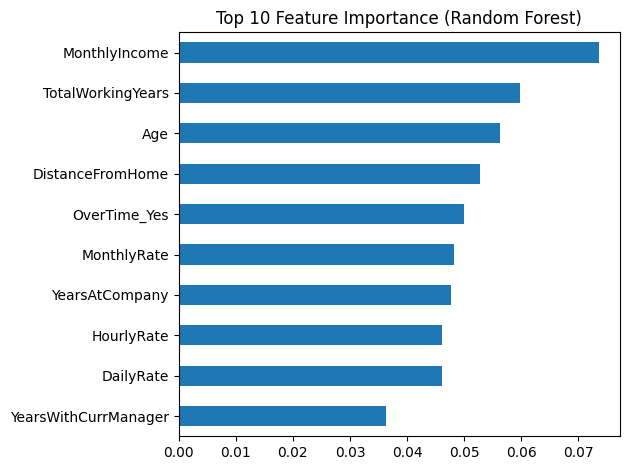

In [86]:
# Feature importance (Random Forest)
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.nlargest(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()